# **Multiple Linear Regression – Multi-Channel Marketing Analysis**

In [13]:
# Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

In [2]:
# Loading dataset
df = pd.read_csv('marketing_sales_data.csv')
# Viewing first 5 rows
df.head()

,TV,Radio,Social Media,Influencer,Sales
0,Low,3.518070,2.293790,Micro,55.261284
1,Low,7.756876,2.572287,Mega,67.574904
2,High,20.348988,1.227180,Micro,272.250108
3,Medium,20.108487,2.728374,Mega,195.102176
4,High,31.653200,7.776978,Nano,273.960377


In [3]:
# checking column names
df.columns

Index(['TV', 'Radio', 'Social Media', 'Influencer', 'Sales'], dtype='object')

## **Exploratory Data Analysis**

In [4]:
# Checking number of rows and columns
df.shape

(572, 5)

In [5]:
# Data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            572 non-null    object 
 1   Radio         572 non-null    float64
 2   Social Media  572 non-null    float64
 3   Influencer    572 non-null    object 
 4   Sales         572 non-null    float64
dtypes: float64(3), object(2)
memory usage: 22.5+ KB


In [6]:
# Checking for duplicates
df.duplicated().sum()

np.int64(0)

In [7]:
# Checking for missing values
df.isna().sum()

TV              0
Radio           0
Social Media    0
Influencer      0
Sales           0
dtype: int64

In [8]:
# Descriptive summary of numeric variables
df.describe()

,Radio,Social Media,Sales
count,572.000000,572.000000,572.000000
mean,17.520616,3.333803,189.296908
std,9.290933,2.238378,89.871581
min,0.109106,0.000031,33.509810
25%,10.699556,1.585549,118.718722
50%,17.149517,3.150111,184.005362
75%,24.606396,4.730408,264.500118
max,42.271579,11.403625,357.788195


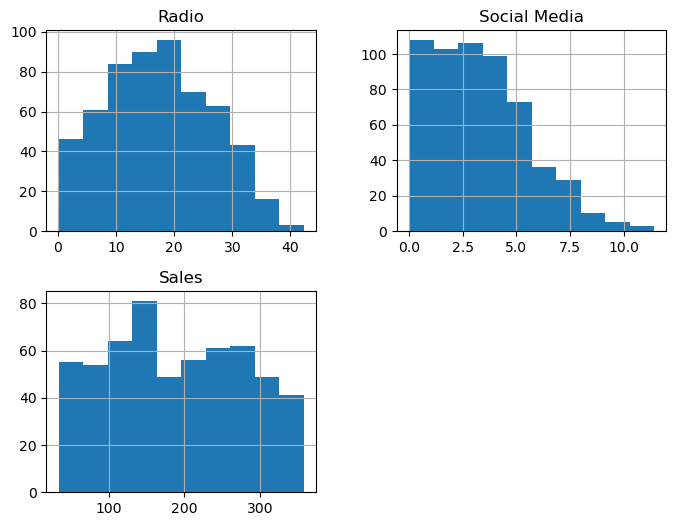

In [9]:
# Distribution of numeric variables

df.hist(figsize=(8,6))
plt.show()

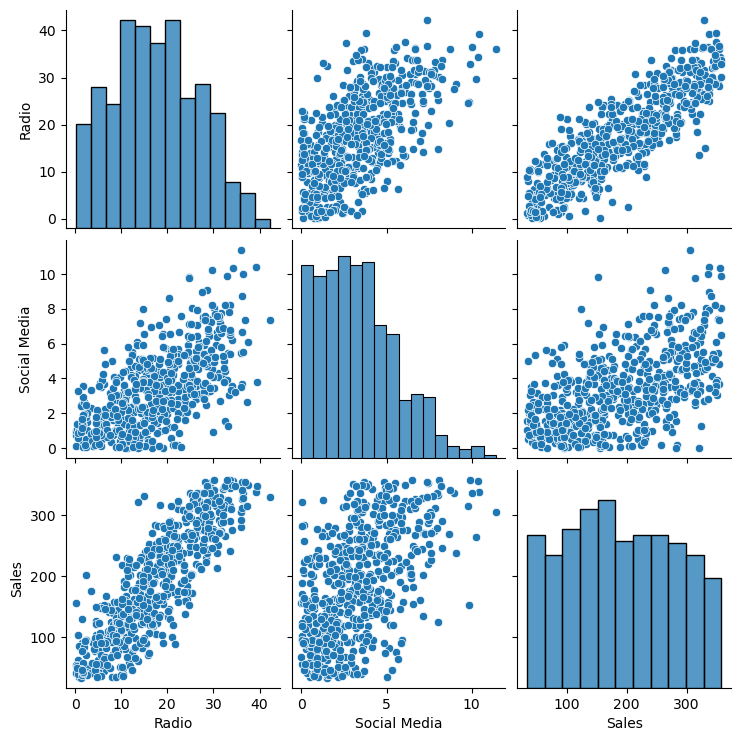

In [10]:
# Checking the relationship between variables in the data
sns.pairplot(df)
plt.show()

## **Feature engineering and encoding**

In [11]:
# Scaling the TV and Influencer columns using Ordinal Encoder

ord_enc = OrdinalEncoder()

cat_feat = df[['TV','Influencer']]
cat_feat_encoded = pd.DataFrame(ord_enc.fit_transform(cat_feat),columns=ord_enc.get_feature_names_out(cat_feat.columns))

# Scaling Radio and Social Media columns using MinMaxScaler

min_max = MinMaxScaler()

num_feat = df[['Radio', 'Social Media']]
num_feat_encoded = pd.DataFrame(min_max.fit_transform(num_feat),columns=num_feat.columns)

# Joining the encoded features into a dataframe
x = pd.concat([cat_feat_encoded,num_feat_encoded],axis=1)
y = df['Sales']

# New dataframe of encoded dataset
df_encoded = pd.concat([x,y],axis=1)
df_encoded.head()

,TV,Influencer,Radio,Social Media,Sales
0,1.0,2.0,0.080853,0.201144,55.261284
1,1.0,1.0,0.181388,0.225565,67.574904
2,0.0,2.0,0.480045,0.107611,272.250108
3,2.0,1.0,0.474341,0.239253,195.102176
4,0.0,3.0,0.748156,0.681973,273.960377


### **Multicollinearity Check**

                    TV  Influencer     Radio  Social Media
TV            1.000000   -0.047143 -0.395841     -0.262081
Influencer   -0.047143    1.000000  0.033915      0.017812
Radio        -0.395841    0.033915  1.000000      0.629941
Social Media -0.262081    0.017812  0.629941      1.000000


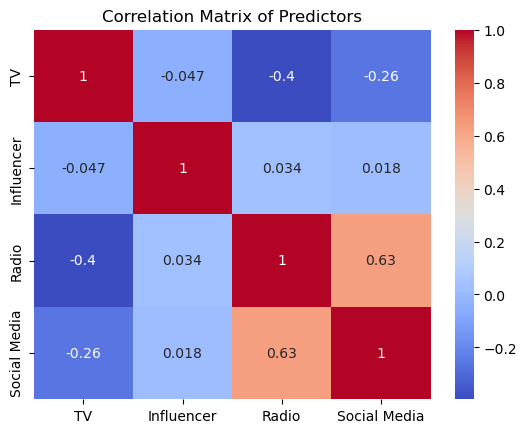

In [15]:
# Checking multicollinearity using Correlation matrix

corr = x.corr()
print(corr)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Predictors')
plt.show()

The correlation matrix above shows that multicollinearity is not a concern in the dataset

In [14]:
# Checking multicollinearity using VIF

vif_data = pd.DataFrame()

vif_data['Feature'] = x.columns

vif_data['VIF'] = [
    variance_inflation_factor(x.values, i)
    for i in range(x.shape[1])
]

vif_data

,Feature,VIF
0,TV,1.809704
1,Influencer,2.514695
2,Radio,5.976654
3,Social Media,5.254640


VIF scores also showed that multicollinearity is not severe

## **Building Multiple Linear Regression Model**

In [16]:
x_sm = sm.add_constant(x)

ols_model = sm.OLS(y, x_sm).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.744
Model:                            OLS   Adj. R-squared:                  0.742
Method:                 Least Squares   F-statistic:                     411.4
Date:                Sun, 21 Jun 2026   Prob (F-statistic):          4.89e-166
Time:                        16:27:13   Log-Likelihood:                -2994.8
No. Observations:                 572   AIC:                             6000.
Df Residuals:                     567   BIC:                             6021.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           62.8065      6.593      9.527   

### **Final Model Equation**

Sales = β0 + β1(TV) + β2(Influencer) + β3(Radio) + β4(Social Media)


Sales = 62.8065 − 10.5653(TV) − 0.3001(Influencer) + 334.6123(Radio) + 0.2438(Social Media)

### **Interpretation of OLS Results**

Key Results

R-squared: 0.744

Adjusted R-squared: 0.742

F-statistic: 411.4

Prob (F-statistic): 4.89e-166

### R Squared interpretation
- The multiple linear regression model explained approximately 74.4% of the variation in Sales (R² = 0.744; Adjusted R² = 0.742), indicating a good model fit after accounting for the number of predictors. 

### F-test & P-value interpretation
- The overall model was statistically significant (F-test, p < 0.001), suggesting that the predictors collectively influence Sales. 

### Coefficient interpretations
- Radio advertising had the strongest positive and statistically significant effect on Sales (β = 334.61, p < 0.001), suggesting that an increase in Radio marketing activity is associated with higher Sales while holding other variables constant.

- Radio advertising is associated with an estimated 334.61 unit increase in Sales.

- TV was also statistically significant (β = -10.57, p < 0.001), while Influencer and Social Media variables were not significant predictors (p > 0.05).

- Moving from a lower TV advertising category to a higher category is associated with an estimated decrease of 10.57 units in Sales, holding other predictors constant.

## **Diagnostic Plots**

In [17]:
# Extracting residuals and fitted values
residuals = ols_model.resid
fitted_values = ols_model.fittedvalues

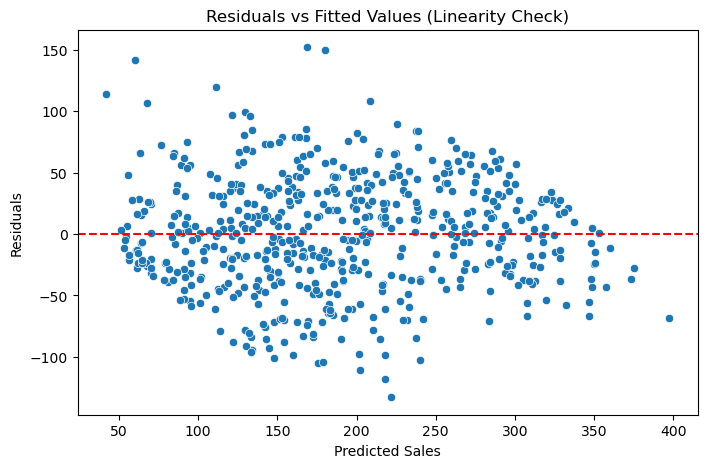

In [19]:
# Linearity check (Residual vs Fitted values)
plt.figure(figsize=(8,5))

sns.scatterplot(x=fitted_values,y=residuals)

plt.axhline(y=0,linestyle='--',color='red')

plt.xlabel('Predicted Sales')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values (Linearity Check)')

plt.show()

The diagram above shows that the linearity assumption is partially satisfied

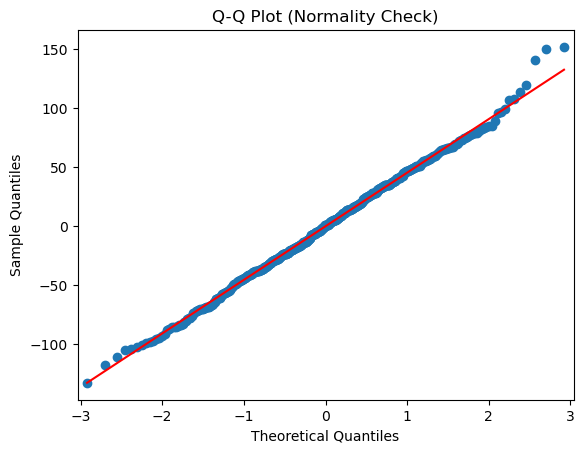

In [22]:
# Normality Check using Q-Q Plot

sm.qqplot(residuals,line='s')

plt.title('Q-Q Plot (Normality Check)')

plt.show()

The Q-Q plot above suggests that the normality assumption was also met

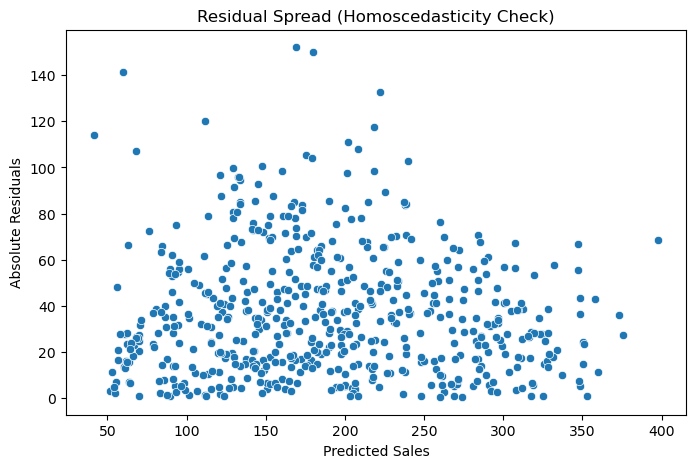

In [21]:
# Homoscedasticity Check (Residual Spread)
plt.figure(figsize=(8,5))

sns.scatterplot(x=fitted_values,y=abs(residuals))

plt.xlabel('Predicted Sales')
plt.ylabel('Absolute Residuals')
plt.title('Residual Spread (Homoscedasticity Check)')

plt.show()

The homoscedasticity assumption is reasonably satisfied

## **Recommendations**

- The company should prioritize allocating a larger proportion of the marketing budget to Radio advertising, as it demonstrated the strongest and most significant positive impact on Sales.

- TV advertising should be reviewed and optimized to improve its effectiveness, while spending on Social Media and Influencer campaigns should be carefully evaluated due to their limited independent contribution to Sales in this model.

- Future budget decisions should continue to be guided by performance data and periodic model reassessment.